<a href="https://colab.research.google.com/github/SriVidyaYeluripati/mlph_w24/blob/dev/sheet08_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [68]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import h5py

## Task 1: CNNs for Galaxy Classification

In [69]:
import numpy as np
import torch
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import h5py
import os

# Step 1: Create data folder if it does not exist
os.makedirs("data", exist_ok=True)

# Step 2: Download the dataset
import urllib.request
_, msg = urllib.request.urlretrieve(
    "http://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5",
    "data/Galaxy10.h5"
)

# Step 3: Class labels
label_names = [
    'Disk, Face-on, No Spiral',
    'Smooth, Completely round',
    'Smooth, in-between round',
    'Smooth, Cigar shaped',
    'Disk, Edge-on, Rounded Bulge',
    'Disk, Edge-on, Boxy Bulge',
    'Disk, Edge-on, No Bulge',
    'Disk, Face-on, Tight Spiral',
    'Disk, Face-on, Medium Spiral',
    'Disk, Face-on, Loose Spiral'
]
n_classes = len(label_names)

# Step 4: Load images and labels
with h5py.File('data/Galaxy10.h5', 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])

images = images.astype(np.float32)
images = np.moveaxis(images, -1, 1)  # Move channels to PyTorch format (C, H, W)
images = torch.from_numpy(images)
labels = torch.from_numpy(labels)

print(f'{images.shape=}, {labels.shape=}')

# Step 5: Filter out invalid labels (255)
valid_mask = labels != 255  # Exclude invalid samples
images = images[valid_mask]
labels = labels[valid_mask]
print(f"Unique labels after filtering: {torch.unique(labels)}")




images.shape=torch.Size([21785, 3, 69, 69]), labels.shape=torch.Size([21785])
Unique labels after filtering: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)


### (a)

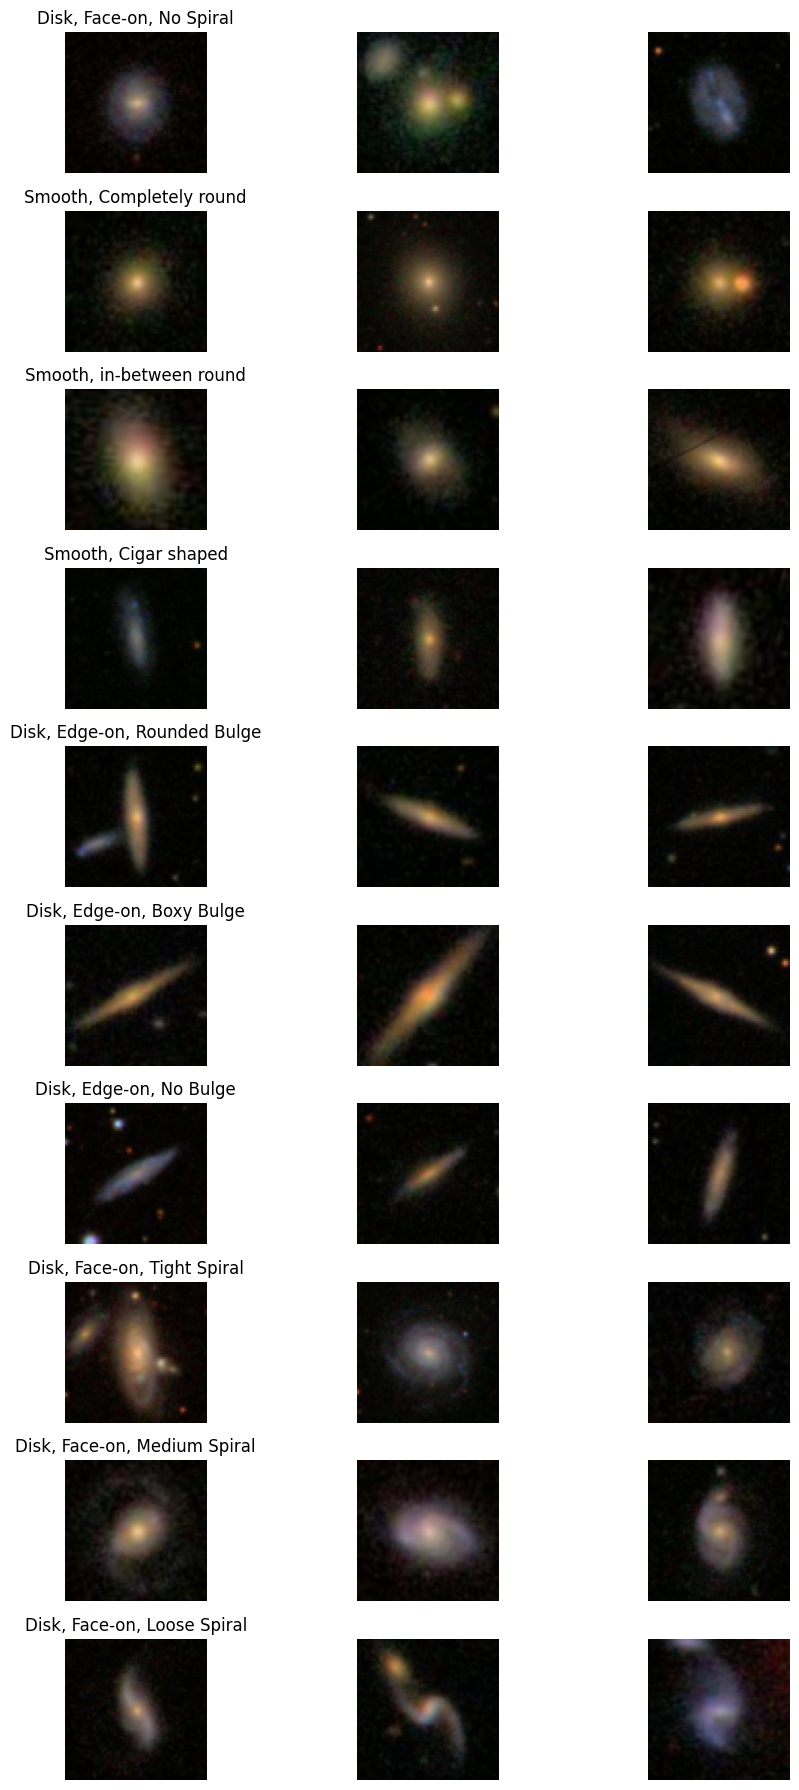

In [66]:
# TODO: plot three samples of each class

fig, axes = plt.subplots(n_classes, 3, figsize=(10, 18))  # Grid of subplots
for label in range(n_classes):
    class_indices = torch.where(labels == label)[0]  # Indices of the current class
    for i in range(3):  # Plot up to 3 samples
        if i < len(class_indices):  # Check if there are enough samples
            img = images[class_indices[i]].permute(1, 2, 0) / 255.0  # Normalize and format image
            axes[label, i].imshow(img)
        axes[label, i].axis("off")  # Remove axes
    axes[label, 0].set_title(label_names[label])  # Set title for the first column
plt.tight_layout()
plt.show()




In [56]:
from torch.utils.data import TensorDataset, DataLoader, random_split
from torchvision.transforms import Normalize

# TODO: Split the data and normalize the images:

# Step 1: Filter out invalid labels (255)
valid_mask = labels != 255  # Create a mask where labels are not 255
images = images[valid_mask]  # Keep only valid images
labels = labels[valid_mask]  # Keep only valid labels

# Check that all labels are valid
print(f"Unique labels in the dataset after filtering: {torch.unique(labels)}")

# Step 2: Split the data into train, validation, and test sets
n = len(images)
train_size = int(0.8 * n)  # 80% for training
val_size = int(0.1 * n)    # 10% for validation
test_size = n - train_size - val_size  # Remaining 10% for testing

# Ensure splits add up correctly
assert train_size + val_size + test_size == n, "Splits do not match total dataset size"

# Randomly split the dataset
train_indices, val_indices, test_indices = random_split(range(n), [train_size, val_size, test_size])

# Step 3: Normalize the images
mean, std = images.mean() / 255.0, images.std() / 255.0  # Compute mean and std
normalize = Normalize(mean, std)

def apply_normalization(image_tensor):
    """Normalize the image tensor to zero mean and unit variance."""
    return normalize(image_tensor / 255.0)

# Normalize the images
images_normalized = torch.stack([apply_normalization(img) for img in images])

# TODO: Create tensordatasets and data loaders:
# Create TensorDatasets for train, validation, and test sets
train_dataset = TensorDataset(images_normalized[train_indices], labels[train_indices])
val_dataset = TensorDataset(images_normalized[val_indices], labels[val_indices])
test_dataset = TensorDataset(images_normalized[test_indices], labels[test_indices])

# Create DataLoaders for each split
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Print the sizes of the splits
print(f"Train set size: {len(train_loader.dataset)}, Validation set size: {len(val_loader.dataset)}, Test set size: {len(test_loader.dataset)}")


Unique labels in the dataset after filtering: tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=torch.uint8)
Train set size: 17428, Validation set size: 2178, Test set size: 2179


### (b)

In [59]:
from torch import nn

class GalaxyCNN(nn.Module):
    def __init__(self):
        super(GalaxyCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 8, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(8, 16, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        self.flatten = nn.Flatten()
        self.fc1 = nn.Sequential(
            nn.Linear(16 * 17 * 17, 64),  # Adjust the input size based on image resolution
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.fc2 = nn.Sequential(
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.5)
        )
        self.fc3 = nn.Linear(32, 10)  # Output layer for 10 classes

    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)  # Output logits
        return x


### (c) + (d) + (e)

Validation Accuracy: 0.44, Validation Loss: 1.32e+00
Epoch 1, Train Loss: 1.6104, Val Loss: 1.3237, Val Acc: 0.4389
Validation Accuracy: 0.44, Validation Loss: 1.27e+00
Epoch 2, Train Loss: 1.3707, Val Loss: 1.2703, Val Acc: 0.4389
Validation Accuracy: 0.48, Validation Loss: 1.14e+00
Epoch 3, Train Loss: 1.2818, Val Loss: 1.1407, Val Acc: 0.4798
Validation Accuracy: 0.58, Validation Loss: 1.07e+00
Epoch 4, Train Loss: 1.2306, Val Loss: 1.0671, Val Acc: 0.5803
Validation Accuracy: 0.61, Validation Loss: 1.04e+00
Epoch 5, Train Loss: 1.1861, Val Loss: 1.0403, Val Acc: 0.6102
Validation Accuracy: 0.64, Validation Loss: 9.52e-01
Epoch 6, Train Loss: 1.1271, Val Loss: 0.9516, Val Acc: 0.6423
Validation Accuracy: 0.66, Validation Loss: 9.35e-01
Epoch 7, Train Loss: 1.0965, Val Loss: 0.9352, Val Acc: 0.6625
Validation Accuracy: 0.67, Validation Loss: 8.84e-01
Epoch 8, Train Loss: 1.0518, Val Loss: 0.8837, Val Acc: 0.6726
Validation Accuracy: 0.68, Validation Loss: 8.66e-01
Epoch 9, Train Loss

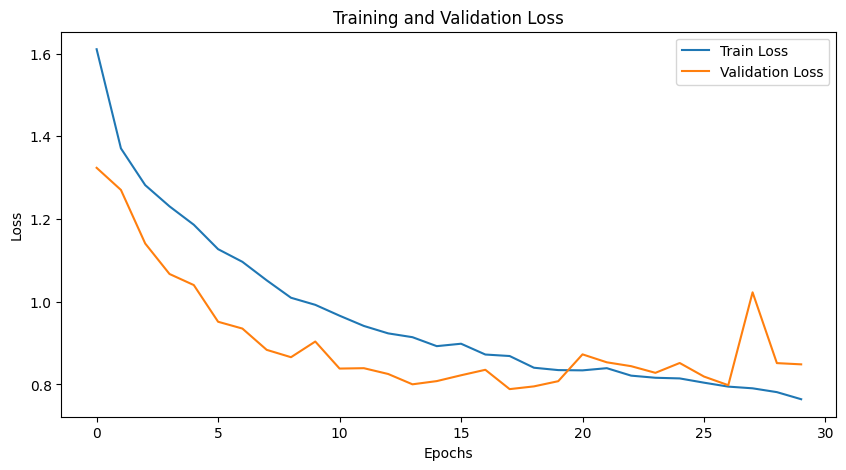

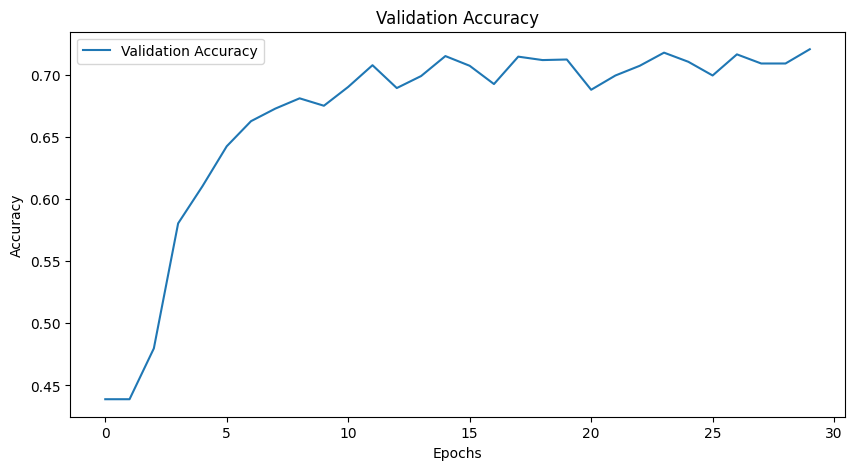

In [60]:
# TODO: Instantiate the model, optimizer and criterion
model = GalaxyCNN()  # Instantiate the CNN model
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)  # Adam optimizer with a learning rate of 1e-3
criterion = torch.nn.CrossEntropyLoss()  # Cross-entropy loss for classification

train_losses = []  # List to store training loss per epoch
val_losses = []  # List to store validation loss per epoch
val_accs = []  # List to store validation accuracy per epoch

# TODO: Implement the training loop, validating after every epoch, and make the requested plots.

# Validation Function
def validate(model, loader):
    model.eval()  # Set the model to evaluation mode
    losses = []  # Store losses
    correct = 0  # Count correct predictions
    total = 0    # Count total predictions

    with torch.no_grad():  # Disable gradient calculation for validation
        for images, labels in loader:
            outputs = model(images)  # Forward pass
            loss = criterion(outputs, labels)  # Compute loss
            losses.append(loss.item())

            # Compute accuracy
            _, predicted = torch.max(outputs, 1)  # Get predicted class with highest score
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    avg_loss = np.mean(np.array(losses))  # Average validation loss
    accuracy = correct / total  # Validation accuracy
    print(f'Validation Accuracy: {accuracy:.2f}, Validation Loss: {avg_loss:.2e}')
    return avg_loss, accuracy

# Training Loop
for epoch in range(30):
    model.train()  # Set model to training mode
    epoch_loss = 0  # To accumulate training loss for the epoch

    for images, labels in train_loader:
        optimizer.zero_grad()  # Clear gradients
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute loss
        loss.backward()  # Backpropagation
        optimizer.step()  # Update model parameters

        epoch_loss += loss.item()  # Accumulate batch loss

    # Compute average training loss for the epoch
    train_loss = epoch_loss / len(train_loader)
    train_losses.append(train_loss)  # Store training loss

    # Validate the model
    val_loss, val_acc = validate(model, val_loader)
    val_losses.append(val_loss)  # Store validation loss
    val_accs.append(val_acc)  # Store validation accuracy

    # Print progress for the current epoch
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

# TODO: Visualize the training loss, validation loss, and validation accuracy

# Plot Training and Validation Loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.show()

# Plot Validation Accuracy
plt.figure(figsize=(10, 5))
plt.plot(val_accs, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Validation Accuracy")
plt.legend()
plt.show()


### Interpretation of Results

#### 1. **Training and Validation Loss**  
- The **training loss** consistently decreases over 30 epochs, which indicates that the model is learning well on the training data.  
- The **validation loss** also decreases initially but starts to fluctuate (minor increases) after around 20 epochs.  
- This behavior suggests **overfitting** might be starting: the model is learning too much about the training data while not generalizing perfectly to unseen data (validation).

**Key Observations**:
- The lowest validation loss is achieved around epochs **18-20**.
- Around epoch **28**, there is a sudden spike in the validation loss (1.02), which confirms overfitting at later stages.


#### 2. **Validation Accuracy**  
- The **validation accuracy** improves significantly during the first few epochs (0.44 → 0.72), which is a good sign that the model is learning effectively.  
- After epoch 18, the accuracy **plateaus around 71%-72%** and does not improve further.  
- The slight fluctuations toward the end suggest overfitting, as the model's performance on the validation set stagnates while the training loss continues to decrease.


### Key Findings  
1. **Overfitting**:
   - The validation loss plateaus and sometimes increases, while the training loss decreases consistently.
   - This suggests the model is starting to memorize the training data instead of generalizing well.

2. **Best Epoch**:
   - The model achieves its best validation accuracy of **72%** and lowest loss around epochs **18-20**.

3. **Overall Performance**:
   - A **72% validation accuracy** is decent for a CNN on this dataset. However, performance can be further improved.



### (e) continued

In [62]:
print(f"Unique predicted labels: {np.unique(test_preds)}")
print(f"Unique ground truth labels: {np.unique(test_labels_all)}")


Unique predicted labels: [0 1 2 3 4 6 7 8]
Unique ground truth labels: [0 1 2 3 4 6 7 8 9]


Test Loss: 0.8829


<Figure size 1000x1000 with 0 Axes>

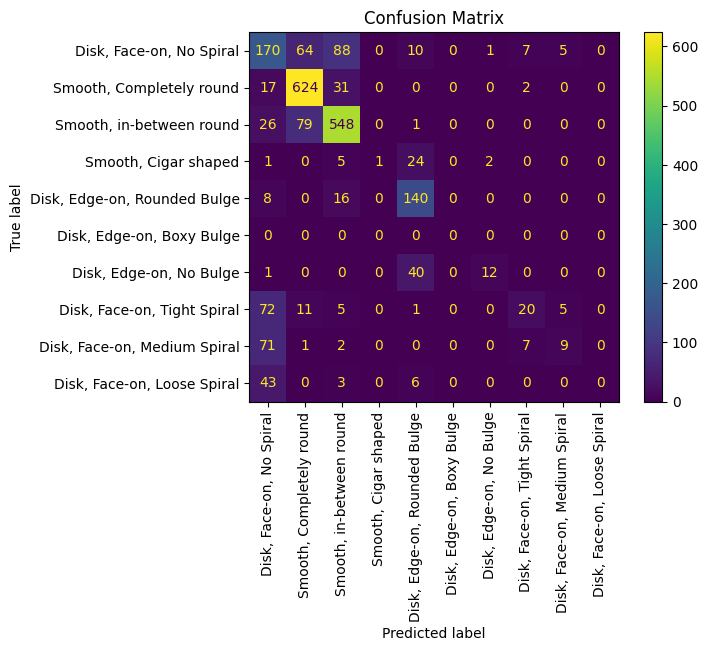

In [63]:
# TODO: Evaluate the best validation model on the test set and create a confusion matrix
# TODO: Evaluate the best validation model on the test set and create a confusion matrix

import torch
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import numpy as np

# Load the best model saved during training (optional, if using early stopping)
# model.load_state_dict(torch.load("best_model.pth"))

# Set the model to evaluation mode
model.eval()

# Step 1: Evaluate the model on the test set
test_losses = []  # To store test loss
test_preds = []   # To store all predictions
test_labels_all = []  # To store all ground truth labels

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images)  # Forward pass
        loss = criterion(outputs, labels)  # Compute test loss
        test_losses.append(loss.item())

        # Get predicted class indices
        _, predicted = torch.max(outputs, 1)
        test_preds.extend(predicted.cpu().numpy())  # Append predictions
        test_labels_all.extend(labels.cpu().numpy())  # Append true labels

# Compute average test loss
avg_test_loss = np.mean(test_losses)
print(f"Test Loss: {avg_test_loss:.4f}")

# Step 2: Confusion Matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Explicitly define all possible class labels [0-9]
all_classes = list(range(10))

# Compute confusion matrix
confusion_mat = confusion_matrix(test_labels_all, test_preds, labels=all_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=confusion_mat, display_labels=label_names)

plt.figure(figsize=(10, 10))
disp.plot(cmap="viridis", xticks_rotation="vertical")
plt.title("Confusion Matrix")
plt.show()




### 1. Missing Predictions for Class 5 and Class 9

  - The model does not predict Class 5 ("Disk, Edge-on, Boxy Bulge") or Class 9 ("Disk, Face-on, Loose Spiral") at all.
  - This indicates that the model struggles to identify these classes.
  - Class Imbalance: These classes might have fewer training samples, making it harder for the model to learn them.
  - Visual Similarity: The features of these classes may look similar to other classes, confusing the model.

### 2. Test Loss

  - The Test Loss is 0.8829, which indicates that the model is reasonably confident in its predictions, but there is room for improvement.
  - The loss value suggests that some predictions are close to being correct but are not quite confident enough (e.g., probabilities distributed over multiple classes).

### 3.  Misclassifications for Some Classes
  - Class 0 ("Disk, Face-on, No Spiral") is often misclassified as Class 1 or Class 2.
  - Class 7 and Class 8 are confused with other disk-related classes.
  - This confusion suggests that the model is struggling to differentiate between visually similar classes.

### 4. Model Accuracy
 - Class 1 ("Smooth, Completely Round") and Class 2 ("Smooth, in-between round") are well-classified.




## 3 Positional Encoding

$ E \in \mathbb{R}^{p\times n} $

$ E_{(2k), i} = \sin\left(i \cdot \exp\left(-\frac{2k \cdot \log(10000)}{p}\right)\right) $

$ E_{(2k+1), i} = \cos\left(i \cdot \exp\left(-\frac{2k \cdot \log(10000)}{p}\right)\right) $